In [ ]:
import numpy as np # linear algebra
import os

In [ ]:


BASE_PATH = '/content/Dataset_BUSI_with_GT'
unique_classes = [path for path in os.listdir(BASE_PATH) if not path.startswith('.')]

print(unique_classes)


['normal', 'benign', 'malignant']


In [ ]:
class_index = [unique_classes[0], unique_classes[2], unique_classes[1]]  # Rearranged order

for i, c in enumerate(class_index):
    print(c, "-", i)



normal - 0
malignant - 1
benign - 2


In [ ]:
images = []
masks = []
labels = []
for folder in os.listdir(BASE_PATH):
    class_path = os.path.join(BASE_PATH, folder)
    for img in os.listdir(class_path):
        if "_mask" not in img:
            img_path = os.path.join(class_path, img)
            msk_path = img_path.replace(".png", "_mask.png")
            # check if mask exist
            if os.path.exists(msk_path):
                images.append(img_path)
                masks.append(msk_path)
                labels.append(folder)

In [ ]:
print(len(images))

780


In [ ]:
images[0]

'/content/Dataset_BUSI_with_GT/normal/normal (124).png'

In [ ]:
input_images_size = 256
channel = 1

In [ ]:
import cv2
import scipy
import scipy.ndimage


def load_image(img_path):
    """ Load single image as Grayscale
    """
    # load image as grayscale
    img = cv2.imread(img_path, 0)
    return img

def padding(img, msk):
    """ Pad images to make them square
    """
    size = np.max(img.shape)

    offset_x = (size-img.shape[0])//2
    offset_y = (size-img.shape[1])//2
    blank_image = np.zeros((size, size))
    blank_mask = np.zeros((size, size))

    blank_image[offset_x:offset_x+img.shape[0],
               offset_y:offset_y+img.shape[1]] = img
    blank_mask[offset_x:offset_x+img.shape[0],
               offset_y:offset_y+img.shape[1]] = msk
    return blank_image, blank_mask

def resize_mask(mask):
    """Resize mask, its different because mask pixel value can change because of resize
    """
    new_size = np.array([input_images_size, input_images_size]) / mask.shape
    mask = scipy.ndimage.interpolation.zoom(mask, new_size)
    return mask

def resize(img):
    """Resize image
    """
    img = cv2.resize(img, (input_images_size, input_images_size))
    return img
def preprocess(img):
  img = img/255.0
  return img

def inverse_preprocess(img):
    """Inverse of preprocessing
    """
    img = img*255
    return img
def load_data(img_path, msk_path, label):
    """Load image, mask and repalce mask value with class index
    0 = normal
    1 = benign
    2 = malignant
    """
    img = load_image(img_path)
    msk = load_image(msk_path)
    img, msk = padding(img, msk)
    label_indx = class_index.index(label)
    msk[msk == 255] = 1
    msk = msk.astype("uint8")
    img = resize(img)
    msk = resize_mask(msk)
    new_mask = np.zeros((input_images_size, input_images_size, 2))
    if label_indx != 0:
        new_mask[:, :, label_indx-1] = msk
#     print(np.unique(msk), label, label_indx)
    return img, new_mask
def load_batch(images, masks, labels):
    """Load Batch of data
    """
    batch_x = []
    batch_y = []
    for i, m, l in zip(images, masks, labels):
        img, msk = load_data(i, m, l)
        img = preprocess(img)
        batch_x.append(img)
        batch_y.append(msk)
    return np.array(batch_x), np.array(batch_y)

<ipython-input-8-2ccde7da84cf>:33: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  mask = scipy.ndimage.interpolation.zoom(mask, new_size)


0.0 230.23975372314453 (256, 256)


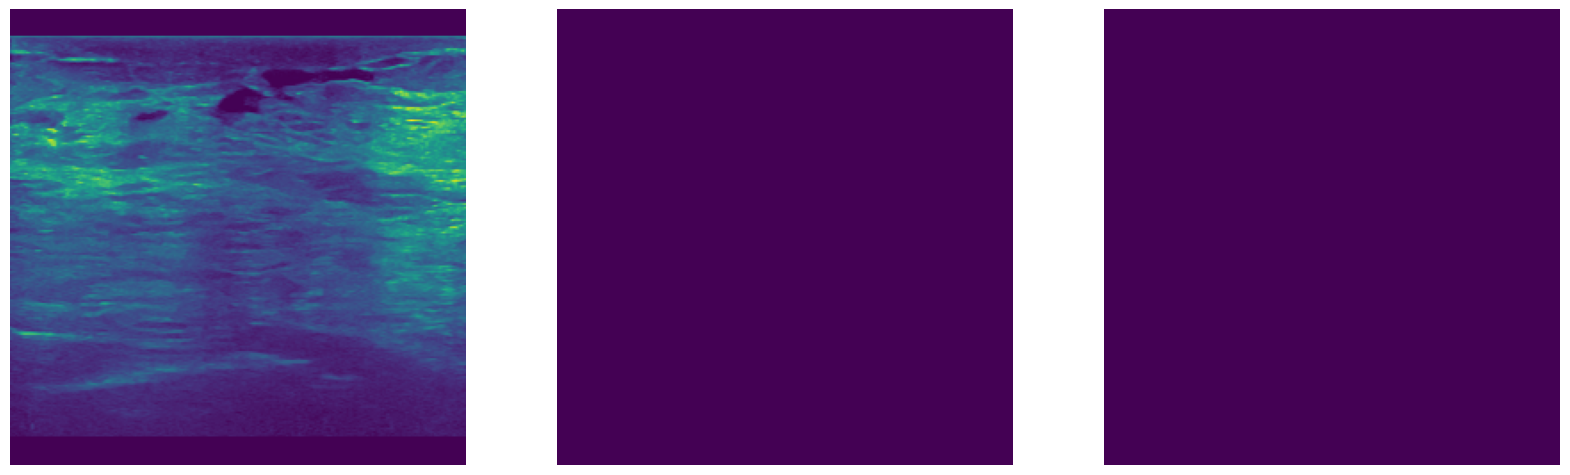

0.0 255.0 (256, 256)


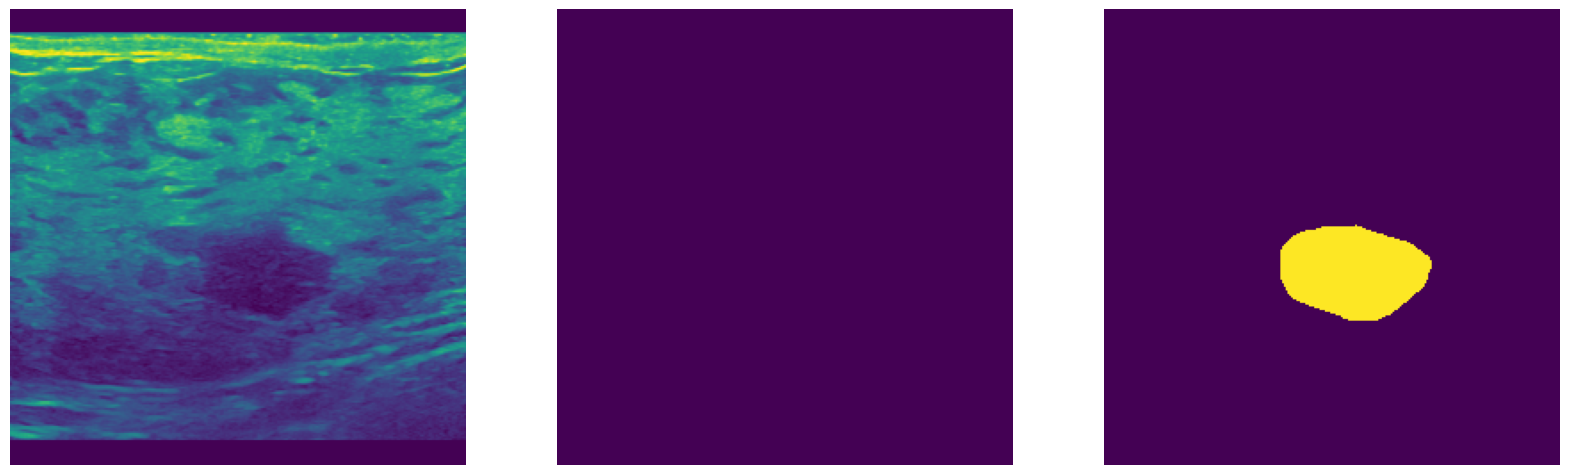

0.0 252.89861297607422 (256, 256)


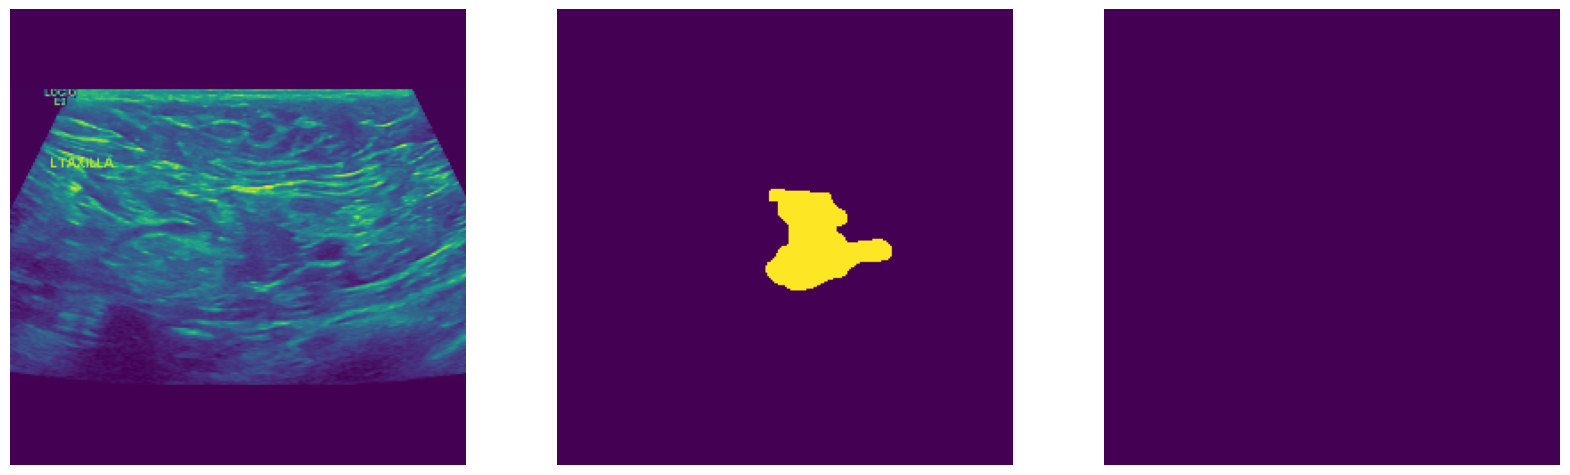

In [ ]:
import matplotlib.pyplot as plt
for i in [0, 500, 600]:
    indx = i
    img, msk = load_data(images[indx], masks[indx], labels[indx])
    print(np.min(img), np.max(img), img.shape)
    plt.figure(figsize=(20, 20))
    plt.subplot(1, 3, 1)
    plt.axis("off")
    plt.imshow(img)
    plt.subplot(1, 3, 2)
    plt.axis("off")
    plt.imshow(msk[:, :, 0])
    plt.subplot(1, 3, 3)
    plt.axis("off")
    plt.imshow(msk[:, :, 1])
    plt.show()

In [ ]:
images = np.array(images)
masks = np.array(masks)
labels = np.array(labels)

In [ ]:
!pip install keras==2.3.1
!pip install tensorflow==2.1.0
!pip install keras_applications==1.0.8
!pip install image-classifiers==1.0.0
!pip install efficientnet==1.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.8/377.8 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires keras>=3.5.0, but you have keras 2.3.1 which is incompatible.
ERROR: Could not find a version that satisfies the requirement tensorflow==2.1.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2

In [ ]:
!pip uninstall keras tensorflow -y
!pip install tensorflow==2.14 keras==2.14 segmentation-models


Found existing installation: Keras 2.3.1
Uninstalling Keras-2.3.1:
  Successfully uninstalled Keras-2.3.1
Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled m

In [ ]:
%env SM_FRAMEWORK=tf.keras

env: SM_FRAMEWORK=tf.keras


In [ ]:
import segmentation_models as sm
import tensorflow as tf
sm.set_framework('tf.keras')

sm.framework()

BACKBONE = 'resnet34'
LR = 0.00001
model = sm.Unet(BACKBONE, classes=2, activation="sigmoid",
                input_shape=(input_images_size,
                             input_images_size, channel),
                encoder_weights=None)

optim = tf.keras.optimizers.Adam(LR)

dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + (1 * focal_loss)
metrics = [sm.metrics.IOUScore(threshold=0.5),
           sm.metrics.FScore(threshold=0.5)]

model.compile(optim, total_loss, metrics)

Segmentation Models: using `tf.keras` framework.


In [ ]:
batch_size = 64
history = {"epoch": []}

for e in range(5):
    print("epoch:", e, end=" > ")
    indexes = list(range(len(images)))
    temp_history = {"loss": [], "IOU": [], "F-Score": []}

    for b in range(0, len(images), batch_size):
        # Avoid out-of-bounds error by ensuring the last batch is valid
        batch_index = indexes[b: min(b + batch_size, len(images))]  # Use min to avoid exceeding the dataset length

        # Loading the batch
        batch_x, batch_y = load_batch(images[batch_index], masks[batch_index], labels[batch_index])
        batch_x = np.expand_dims(batch_x, axis=-1)
        batch_y = np.expand_dims(batch_y, axis=-1)
        batch_y = batch_y.astype("float32")

        # Train on batch
        loss = model.train_on_batch(batch_x, batch_y)

        # Append loss & metrics
        temp_history["loss"].append(loss[0])
        temp_history["IOU"].append(loss[1])
        temp_history["F-Score"].append(loss[2])

    # Print epoch stats
    print("loss", np.round(np.mean(temp_history["loss"]), 4),
          "IOU", np.round(np.mean(temp_history["IOU"]), 4),
          "F-Score", np.round(np.mean(temp_history["F-Score"]), 4))

    history["epoch"].append(temp_history)

# Save model weights
model.save_weights("breast_tumor_segmentation")



epoch: 0 > 

<ipython-input-8-2ccde7da84cf>:33: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  mask = scipy.ndimage.interpolation.zoom(mask, new_size)


loss 1.0787 IOU 0.0273 F-Score 0.0511
epoch: 1 > loss 1.0599 IOU 0.0327 F-Score 0.0604
epoch: 2 > loss 1.0493 IOU 0.0371 F-Score 0.0673
epoch: 3 > loss 1.0414 IOU 0.0426 F-Score 0.0755
epoch: 4 > loss 1.0347 IOU 0.0488 F-Score 0.0841


<ipython-input-8-2ccde7da84cf>:33: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  mask = scipy.ndimage.interpolation.zoom(mask, new_size)


0.0 230.23975372314453 (256, 256)
(256, 256)
1/1 [==============================] - 2s 2s/step


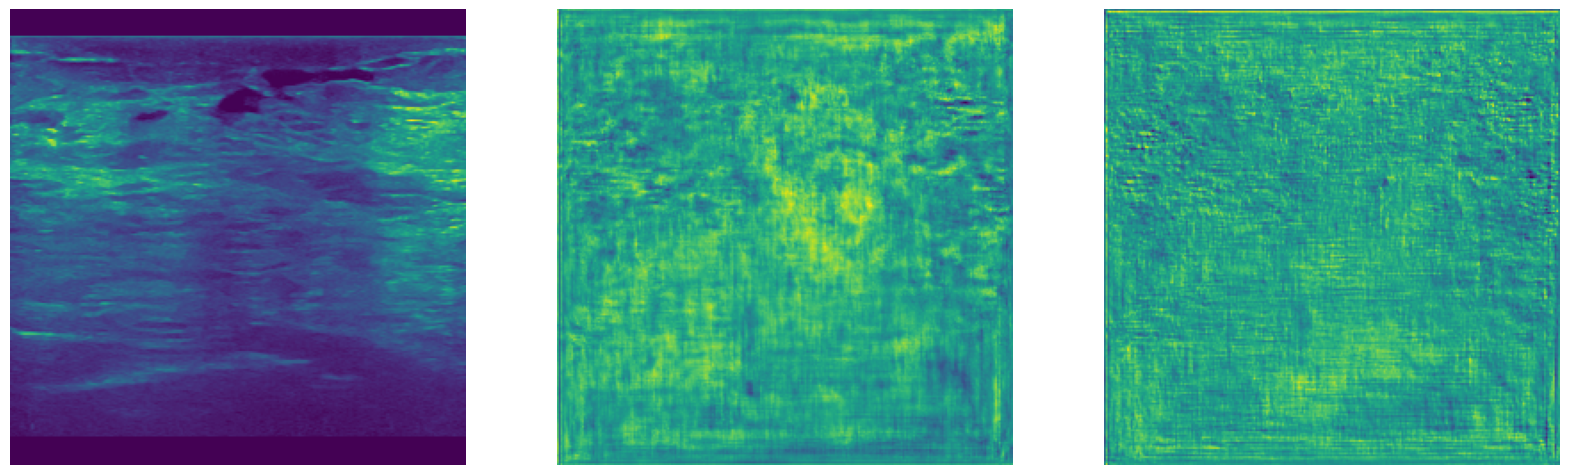

0.0 255.0 (256, 256)
(256, 256)
1/1 [==============================] - 1s 941ms/step


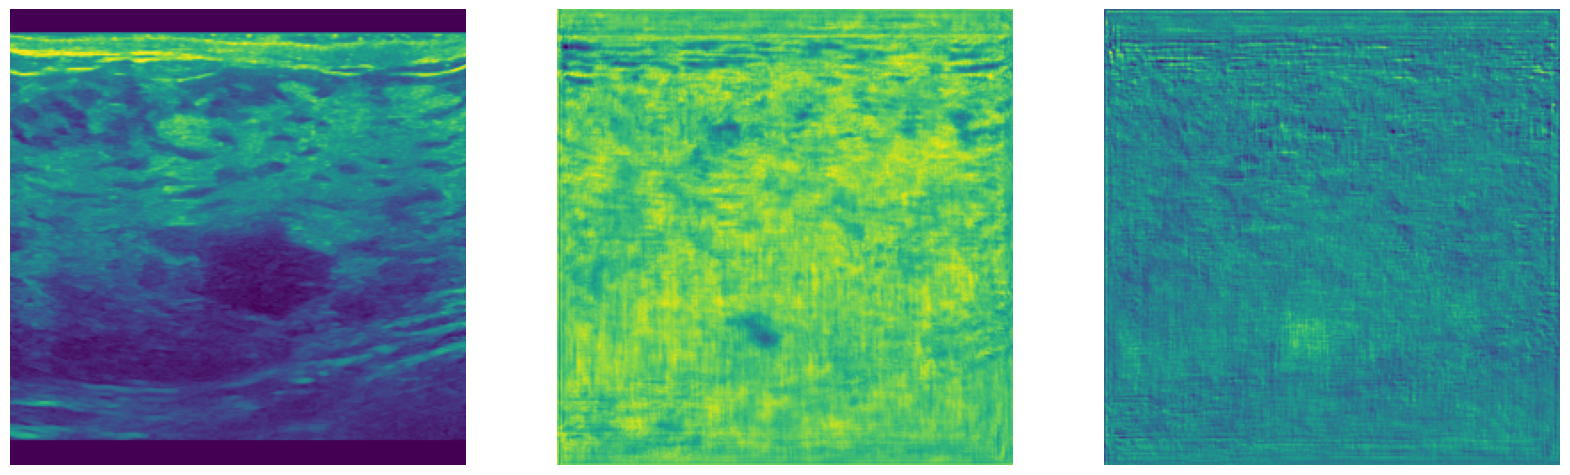

0.0 252.89861297607422 (256, 256)
(256, 256)
1/1 [==============================] - 0s 413ms/step


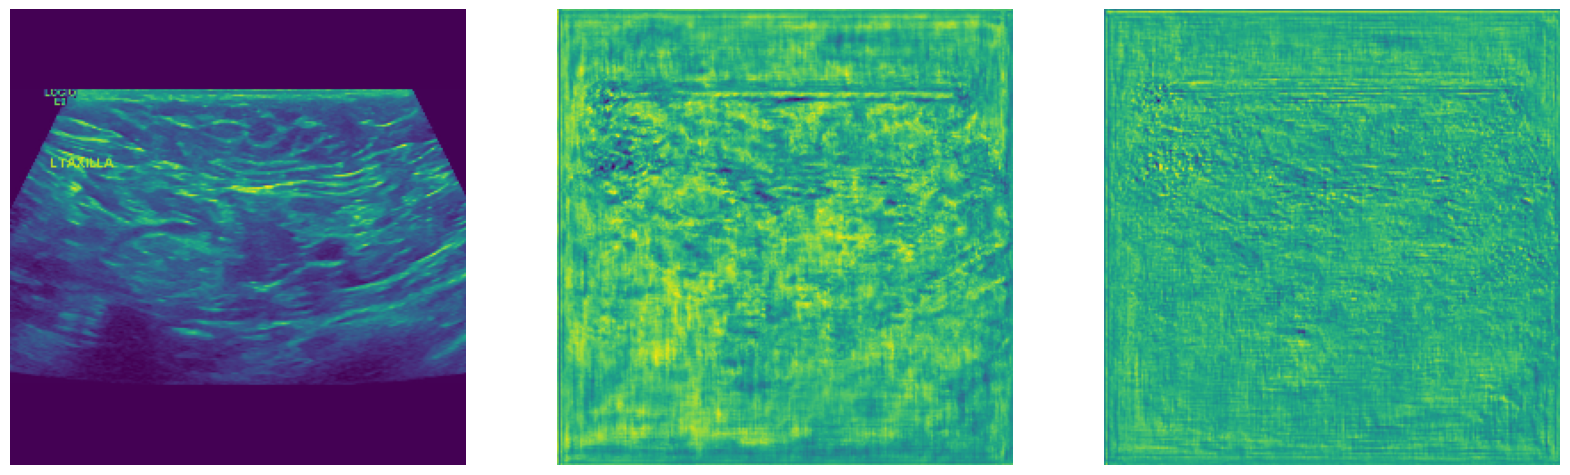

In [ ]:
import matplotlib.pyplot as plt
for i in [0, 500, 600]:
    indx = i
    img, msk = load_data(images[indx], masks[indx], labels[indx])
    print(np.min(img), np.max(img), img.shape)
    print(img.shape)

    img2 = preprocess(img)
    pred = model.predict(np.array([img2]))
    pred = pred[0]

    plt.figure(figsize=(20, 20))
    plt.subplot(1, 3, 1)
    plt.axis("off")
    plt.imshow(img)
    plt.subplot(1, 3, 2)
    plt.axis("off")
    plt.imshow(pred[:, :, 0])
    plt.subplot(1, 3, 3)
    plt.axis("off")
    plt.imshow(pred[:, :, 1])
    plt.show()

In [ ]:
import numpy as np
import cv2

def extract_tumor_features(mask):
    """Extract features from the tumor mask."""
    # Calculate tumor area (number of pixels)
    tumor_area = np.sum(mask > 0)

    # Calculate tumor bounding box and size
    coords = np.column_stack(np.where(mask > 0))
    if len(coords) > 0:
        x, y, w, h = cv2.boundingRect(coords)
        tumor_size = max(w, h)  # Maximum dimension of the tumor
        circularity = (4 * np.pi * tumor_area) / (cv2.arcLength(coords, True) ** 2)  # Circularity measure
    else:
        tumor_size = 0
        circularity = 0

    return {
        'tumor_area': tumor_area,
        'tumor_size': tumor_size,
        'circularity': circularity
    }

In [ ]:
def predict_stage_and_risk(features):
    """Predict cancer stage and risk level based on tumor features."""
    tumor_size = features['tumor_size']

    # Rule-based stage prediction
    if tumor_size == 0:
        stage = 'Normal'
        risk = 'None'  # No risk if normal
    elif tumor_size < 30:
        stage = 'Stage I'
        risk = 'Low'  # Stage I = Low Risk
    elif tumor_size < 70:
        stage = 'Stage II'
        risk = 'Medium'  # Stage II = Medium Risk
    else:
        stage = 'Stage III'
        risk = 'High'  # Stage III = High Risk

    return stage, risk

In [ ]:
for i in [10,250,300,500]:  # Example indices
    img, msk = load_data(images[i], masks[i], labels[i])
    features = extract_tumor_features(msk[:, :, 0] + msk[:, :, 1])  # Combine both masks if needed
    stage, risk = predict_stage_and_risk(features)

    print(f"Image {i}:")
    print(f"Tumor Features: {features}")
    print(f"Predicted Stage: {stage}, Predicted Risk: {risk}")
    print("-" * 40)

Image 10:
Tumor Features: {'tumor_area': 0, 'tumor_size': 0, 'circularity': 0}
Predicted Stage: Normal, Predicted Risk: None
----------------------------------------
Image 250:
Tumor Features: {'tumor_area': 5448, 'tumor_size': 100, 'circularity': 0.0005862695897519516}
Predicted Stage: Stage III, Predicted Risk: High
----------------------------------------
Image 300:
Tumor Features: {'tumor_area': 2307, 'tumor_size': 66, 'circularity': 0.0014013125011569762}
Predicted Stage: Stage II, Predicted Risk: Medium
----------------------------------------
Image 500:
Tumor Features: {'tumor_area': 3445, 'tumor_size': 85, 'circularity': 0.0009294254597494887}
Predicted Stage: Stage III, Predicted Risk: High
----------------------------------------


<ipython-input-8-2ccde7da84cf>:33: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  mask = scipy.ndimage.interpolation.zoom(mask, new_size)


<ipython-input-8-2ccde7da84cf>:33: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  mask = scipy.ndimage.interpolation.zoom(mask, new_size)


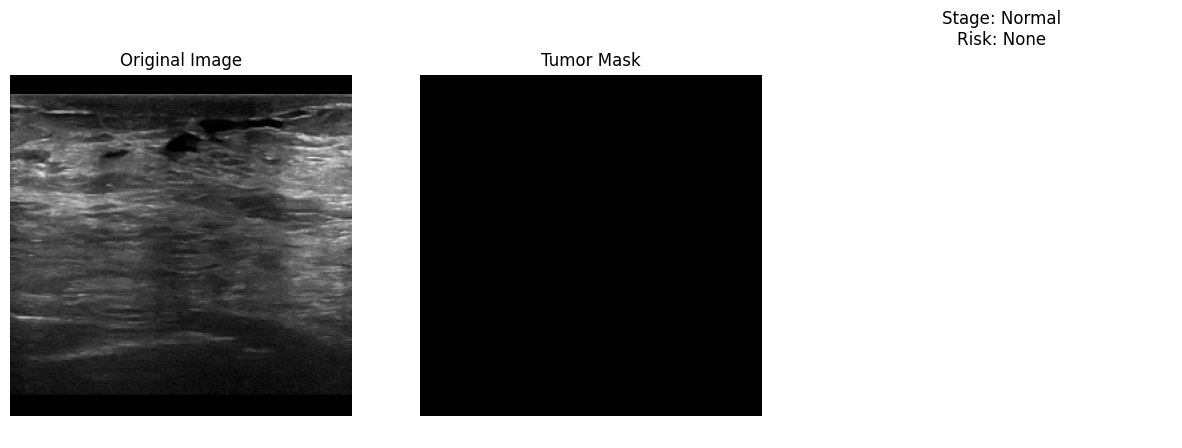

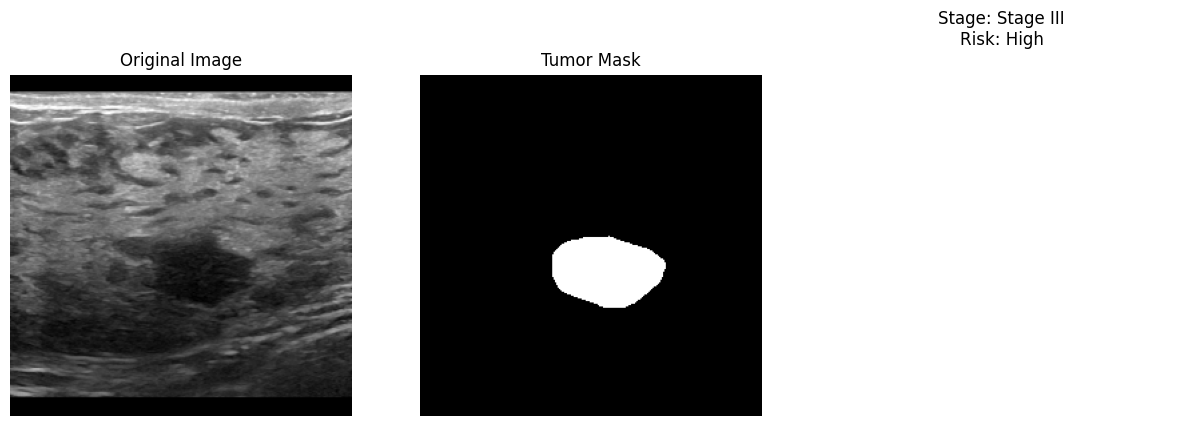

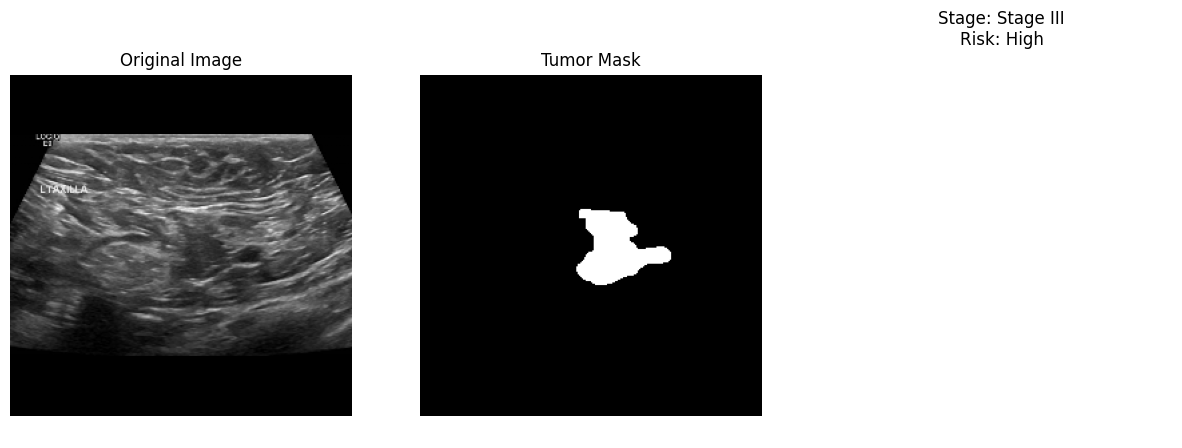

In [ ]:
import matplotlib.pyplot as plt

for i in [0, 500, 600]:  # Example indices
    img, msk = load_data(images[i], masks[i], labels[i])
    features = extract_tumor_features(msk[:, :, 0] + msk[:, :, 1])
    stage, risk = predict_stage_and_risk(features)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Tumor Mask")
    plt.imshow(msk[:, :, 0] + msk[:, :, 1], cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Stage: {stage}\nRisk: {risk}")
    plt.axis("off")
    plt.show()